In [1]:
import os
import pandas as pd
import joblib

# Thiết lập đường dẫn tới thư mục artifacts (nơi chứa file pkl và csv)
# Nếu file .ipynb nằm cùng thư mục với file script cũ, BASE_DIR sẽ là thư mục cha.
# Bạn có thể điều chỉnh lại đường dẫn cho đúng với cấu trúc thư mục của mình.
BASE_DIR = os.path.dirname(os.getcwd()) # Lấy thư mục cha của thư mục hiện tại
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')

print(f"📂 Thư mục chứa artifacts: {ARTIFACTS_DIR}")

📂 Thư mục chứa artifacts: d:\FPTU_Study\SU2026\ADY201m\Project_ADY201m_GR01_AI2009_H1\artifacts


In [2]:
# 1. Load các tập dữ liệu Train/Test đã chia sẵn
X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train_tree.csv'))
X_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_test_tree.csv'))
y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train_tree.csv'))
y_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_test_tree.csv'))

# 2. Load Pipeline tiền xử lý (chỉ chứa bước One-Hot Encoder)
preprocessing_pipeline = joblib.load(os.path.join(ARTIFACTS_DIR, 'tree_preprocessing_pipeline.pkl'))

print("✅ Đã load thành công dữ liệu và pipeline vào Notebook!")
print(f"Kích thước tập X_train gốc: {X_train.shape}")

✅ Đã load thành công dữ liệu và pipeline vào Notebook!
Kích thước tập X_train gốc: (5634, 18)


In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train.values.ravel())

print("✅ Random Forest training completed!")

✅ Random Forest training completed!


In [4]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Evaluation function displaying 5 core classification metrics
def evaluate_model(y_true, y_pred, y_prob):
    print(f"--- MODEL PERFORMANCE METRICS ---")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}\n")

evaluate_model(y_test, y_pred, y_prob,)

--- MODEL PERFORMANCE METRICS ---
Accuracy  : 0.7750
Precision : 0.5578
Recall    : 0.7353
F1-Score  : 0.6344
ROC-AUC   : 0.8519



In [6]:
import pandas as pd

# 1. Tạo Feature Importance DataFrame
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# 2. Dùng Regex để xóa triệt để tiền tố 'encoder__' hoặc 'remainder__' và xóa khoảng trắng thừa
importance_df['Feature'] = (
    importance_df['Feature']
    .str.replace(r'^(encoder__|remainder__)', '', regex=True)
    .str.strip()
)

# Bảng từ điển map TOÀN BỘ 25 cột (có thể dư dả thoải mái không sao)
custom_names = {
    # Nhóm biến sinh ra từ One-Hot Encoding
    'Dependents_Yes': 'Dependents: Yes',
    'PaymentMethod_Credit card (automatic)': 'Payment Method: Credit Card (Auto)',
    'PaymentMethod_Electronic check': 'Payment Method: Electronic Check',
    'PaymentMethod_Mailed check': 'Payment Method: Mailed Check',
    'InternetService_Fiber optic': 'Internet Service: Fiber Optic',
    'InternetService_No': 'Internet Service: None',
    'tenure_group' : 'Tenure Group',
    'tenure_group_13-24 months': 'Tenure Group: 13-24 Months',
    'tenure_group_25-36 months': 'Tenure Group: 25-36 Months',
    'tenure_group_37-48 months': 'Tenure Group: 37-48 Months',
    'tenure_group_49-60 months': 'Tenure Group: 49-60 Months',
    'tenure_group_61-72 months': 'Tenure Group: 61-72 Months',
    
    # Nhóm biến số / Nhị phân giữ nguyên (Remainder)
    'SeniorCitizen': 'Senior Citizen Status',
    'Partner': 'Partner Status',
    'Tenure': 'Tenure (Months)',
    'Contract': 'Contract Type',
    'PaperlessBilling': 'Paperless Billing',
    'MonthlyCharges': 'Monthly Charges',
    'TotalCharges': 'Total Charges',
    'OnlineSecurity': 'Online Security Opt-in',
    'OnlineBackup': 'Online Backup Opt-in',
    'DeviceProtection': 'Device Protection Opt-in',
    'TechSupport': 'Technical Support Opt-in',
    
    # Nhóm Feature Engineering 
    'service_diversity': 'Service Diversity Score',
    'monthly_charges_ratio': 'Monthly Charges Ratio',
    'is_paperless_electronic': 'Paperless & Auto-Payment Combo'
}

# 3. Áp dụng Mapping (Chỉnh sửa ở đây)
# Áp dụng trực tiếp lên cột 'Feature'. .map() sẽ tự tra cứu 18 cột, dư 7 key trong dict cũng không báo lỗi.
importance_df['Feature'] = importance_df['Feature'].map(custom_names).fillna(importance_df['Feature'])

# 4. Sắp xếp theo độ quan trọng (giảm dần)
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# 5. Chuyển đổi sang phần trăm (%)
importance_df["Importance (%)"] = (
    importance_df["Importance"] * 100
).round(2)

# ==========================================
# 6. IN KẾT QUẢ RA MÀN HÌNH BẰNG HÀM PRINT
# ==========================================

print("--- TOP 10 FEATURE IMPORTANCES ---")
print("-" * 55)

# Chọn in ra 2 cột "Feature" và "Importance (%)" dưới dạng text, ẩn cột index
cols_to_print = ["Feature", "Importance (%)"]

# In ra Top 10 (Nếu bạn muốn in tất cả 18 cột, chỉ cần xóa chữ .head(10) đi)
print(importance_df[cols_to_print].head(10).to_string(index=False))
print("-" * 55)

--- TOP 10 FEATURE IMPORTANCES ---
-------------------------------------------------------
                Feature  Importance (%)
          Contract Type           18.62
        Tenure (Months)           13.49
        Monthly Charges           11.05
  Monthly Charges Ratio           10.76
          Total Charges           10.53
             Dependents            8.04
           Tenure Group            6.34
        InternetService            5.44
          PaymentMethod            3.22
Service Diversity Score            3.05
-------------------------------------------------------


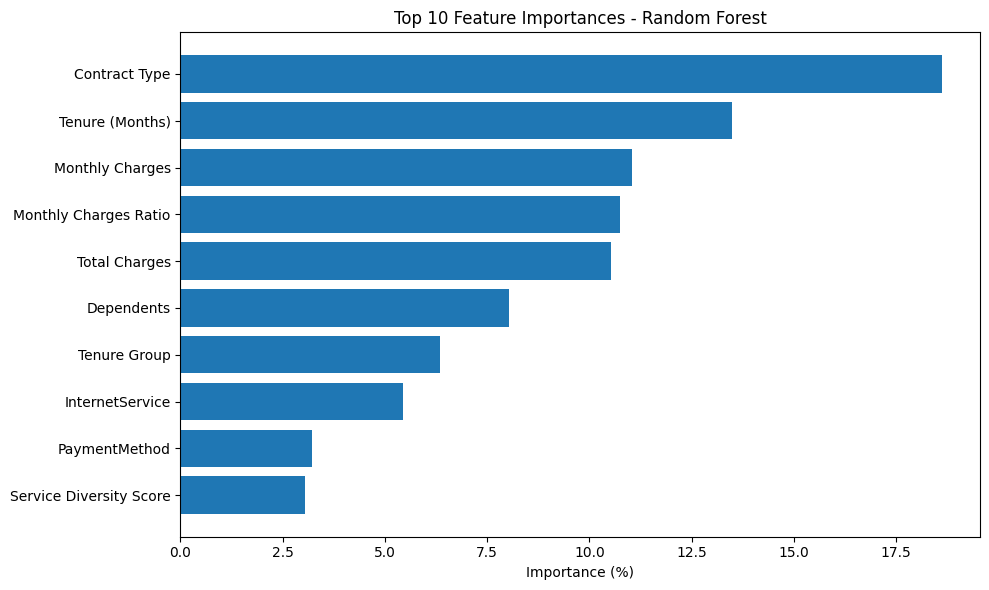

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
# Chỉ lấy Top 10
top10 = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"],
    top10["Importance (%)"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance (%)")
plt.ylabel("")
plt.title("Top 10 Feature Importances - Random Forest")

plt.tight_layout()
plt.savefig(
    "rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
